# 01 — Signal Basics

Neste notebook vamos explorar os fundamentos de um sinal de áudio digital.

Objetivos:

- Gerar uma onda senoidal;
- Entender frequência, amplitude, duração e sample rate;
- Visualizar um sinal no domínio do tempo;
- Relacionar a representação matemática com os samples digitais;
- Observar experimentalmente como cada parâmetro altera o sinal.

## 1. O que é um sinal de áudio?

Um sinal de áudio pode ser representado como uma função que descreve a amplitude do som ao longo do tempo.

Para uma onda senoidal, podemos usar:

$$
x(t) = A\sin(2\pi ft)
$$

Onde:

- $A$ = amplitude;
- $f$ = frequência em Hertz (Hz);
- $t$ = tempo em segundos.

No computador, porém, não armazenamos todos os valores possíveis de $t$.

Armazenamos apenas uma sequência de amostras.

## 2. Representação digital

Um sinal digital é representado por samples.

Podemos representar uma onda senoidal como:

$$
x[n] = A\sin\left(2\pi f\frac{n}{F_s}\right)
$$

Onde:

- $n$ = índice da amostra;
- $A$ = amplitude;
- $f$ = frequência;
- $F_s$ = sample rate.

O tempo de cada sample pode ser obtido por:

$$
t = \frac{n}{F_s}
$$

Portanto, nosso primeiro objetivo será transformar essa fórmula em código.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from nova_audio.core.signal import generate_sine

## 3. Gerando nossa primeira onda

Vamos começar com:

- Frequência: 440 Hz
- Amplitude: 1.0
- Sample rate: 44.100 Hz
- Duração: 1 segundo

440 Hz é uma frequência tradicionalmente usada como referência para a nota A4.

In [13]:
frequency = 440
amplitude = 1.0
sample_rate = 44100
duration = 1.0

In [14]:
signal = generate_sine(
    frequency=frequency,
    amplitude=amplitude,
    sample_rate=sample_rate,
    duration=duration,
)

In [15]:
print(f"Quantidade de samples: {len(signal)}")
print(f"Primeiro sample: {signal[0]}")
print(f"Maior valor: {np.max(signal)}")
print(f"Menor valor: {np.min(signal)}")

Quantidade de samples: 44100
Primeiro sample: 0.0
Maior valor: 0.9999997462578869
Menor valor: -0.9999997462578869


## 4. Visualizando o sinal

Nosso sinal possui 1 segundo de duração.

Porém, visualizar os 44.100 samples de uma vez não é muito útil.

Vamos visualizar apenas os primeiros 10 ms.

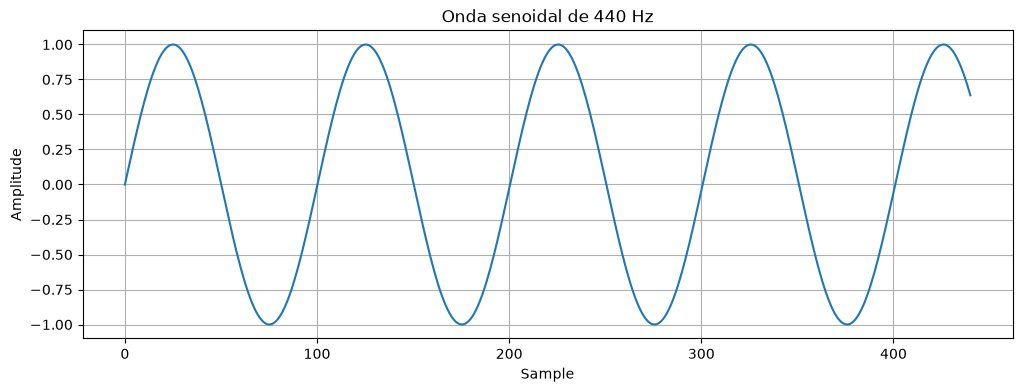

In [16]:
samples_to_plot = int(sample_rate * 0.01)

plt.figure(figsize=(12, 4))
plt.plot(signal[:samples_to_plot])

plt.title("Onda senoidal de 440 Hz")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

## 5. Sample versus tempo

Até agora o eixo X mostra o índice do sample.

Podemos transformar esse índice em segundos usando:

$$
t = \frac{n}{F_s}
$$

Assim podemos visualizar o sinal no domínio do tempo.

In [17]:
time = np.arange(len(signal)) / sample_rate

time[:10]

array([0.00000000e+00, 2.26757370e-05, 4.53514739e-05, 6.80272109e-05,
       9.07029478e-05, 1.13378685e-04, 1.36054422e-04, 1.58730159e-04,
       1.81405896e-04, 2.04081633e-04])

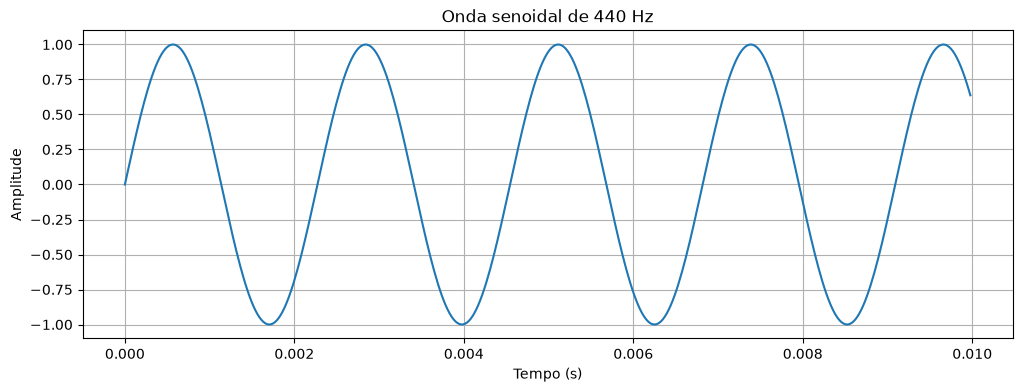

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(
    time[:samples_to_plot],
    signal[:samples_to_plot],
)

plt.title("Onda senoidal de 440 Hz")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

# 6. Experimento: frequência

Agora vamos alterar apenas a frequência.

Vamos comparar:

- 220 Hz
- 440 Hz
- 880 Hz

Todo o restante permanecerá igual.

Antes de executar, tente prever:

**O que acontecerá com a forma da onda quando aumentarmos a frequência?**

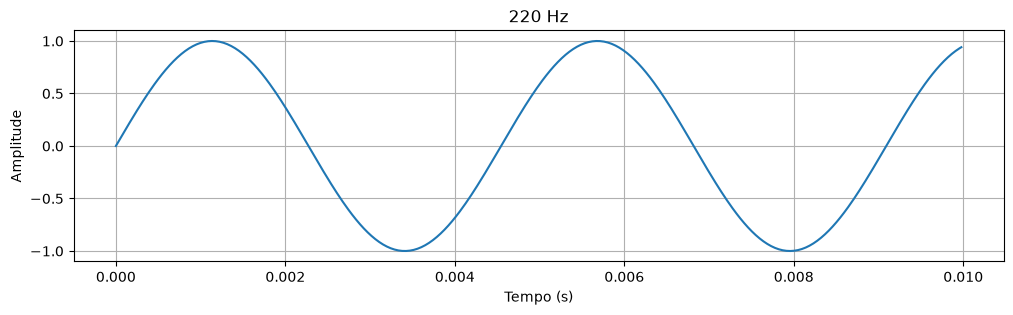

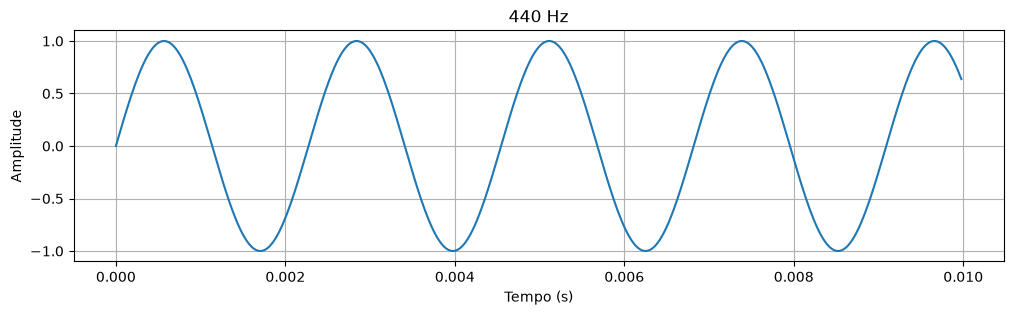

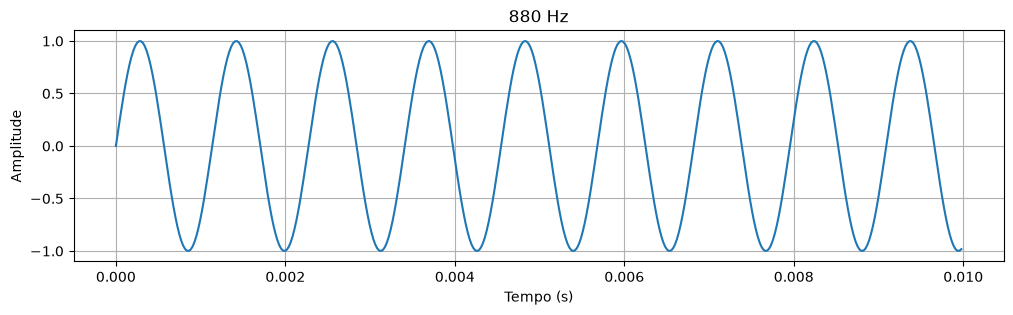

In [19]:
frequencies = [220, 440, 880]

for frequency in frequencies:
    signal = generate_sine(
        frequency=frequency,
        amplitude=1.0,
        sample_rate=44100,
        duration=0.01,
    )

    time = np.arange(len(signal)) / 44100

    plt.figure(figsize=(12, 3))
    plt.plot(time, signal)

    plt.title(f"{frequency} Hz")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()

    plt.show()

### Observação

Compare os três gráficos.

Responda:

1. Qual possui mais ciclos no mesmo intervalo de tempo?
2. Qual possui menos?
3. A amplitude mudou?
4. O que parece estar sendo controlado pela frequência?

# 7. Experimento: amplitude

Agora vamos manter a frequência constante em 440 Hz.

Vamos alterar somente a amplitude:

- 0.25
- 0.5
- 1.0

Antes de executar:

**O que você espera que aconteça com a altura da onda?**

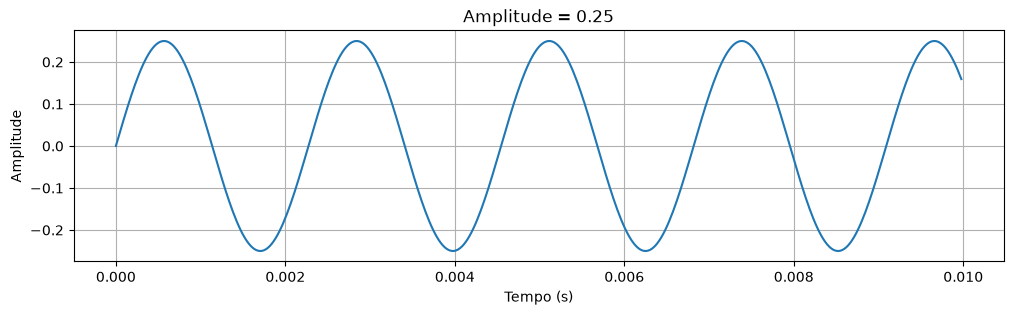

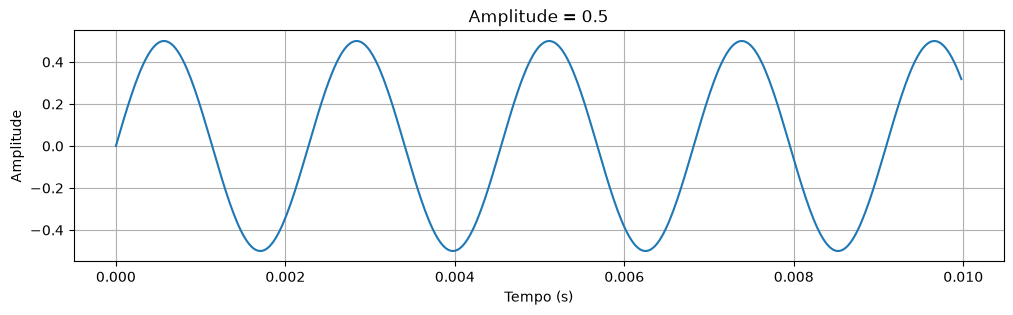

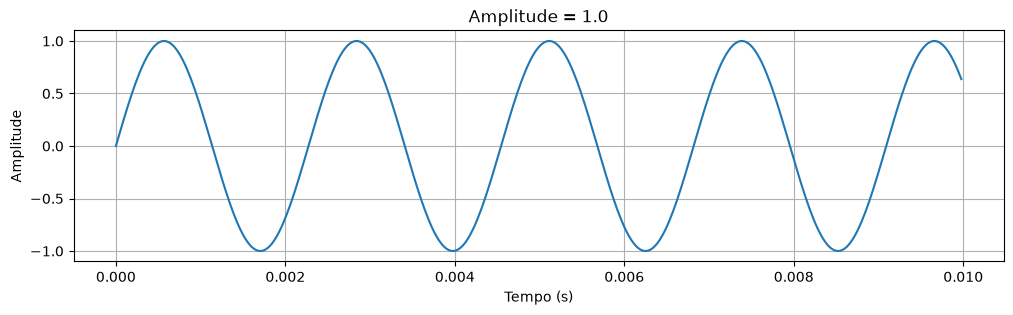

In [20]:
amplitudes = [0.25, 0.5, 1.0]

for amplitude in amplitudes:
    signal = generate_sine(
        frequency=440,
        amplitude=amplitude,
        sample_rate=44100,
        duration=0.01,
    )

    time = np.arange(len(signal)) / 44100

    plt.figure(figsize=(12, 3))
    plt.plot(time, signal)

    plt.title(f"Amplitude = {amplitude}")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()

    plt.show()

### Observação

Compare os gráficos.

Responda:

1. A quantidade de ciclos mudou?
2. A altura da onda mudou?
3. O que parece estar sendo controlado pela amplitude?

# 8. Experimento: duração

Agora vamos manter frequência, amplitude e sample rate constantes.

Vamos alterar somente a duração:

- 0.01 s
- 0.1 s
- 1.0 s

Antes de executar:

**O que você espera que aconteça com a quantidade de samples?**

In [21]:
durations = [0.01, 0.1, 1.0]

for duration in durations:
    signal = generate_sine(
        frequency=440,
        amplitude=1.0,
        sample_rate=44100,
        duration=duration,
    )

    print(
        f"Duração: {duration}s | "
        f"Samples: {len(signal)}"
    )

Duração: 0.01s | Samples: 441
Duração: 0.1s | Samples: 4410
Duração: 1.0s | Samples: 44100


# 9. Experimento: sample rate

Agora chegamos a uma variável muito importante.

Vamos gerar o mesmo sinal utilizando:

- 8.000 Hz
- 16.000 Hz
- 44.100 Hz

A frequência será sempre 440 Hz.

Antes de executar:

**O que você espera que aconteça com a quantidade de samples?**

In [22]:
sample_rates = [8000, 16000, 44100]

for sample_rate in sample_rates:
    signal = generate_sine(
        frequency=440,
        amplitude=1.0,
        sample_rate=sample_rate,
        duration=0.01,
    )

    print(
        f"Sample rate: {sample_rate} Hz | "
        f"Samples: {len(signal)}"
    )

Sample rate: 8000 Hz | Samples: 80
Sample rate: 16000 Hz | Samples: 160
Sample rate: 44100 Hz | Samples: 441


## 10. O que aprendemos?

Preencha as relações abaixo com suas próprias palavras:

**Frequência**

A frequência controla:

> ...

**Amplitude**

A amplitude controla:

> ...

**Duração**

A duração controla:

> ...

**Sample rate**

O sample rate controla:

> ...

In [ ]:
from IPython.display import Audio

frequency = 1880
amplitude = 1.0
sample_rate = 44100
duration = 1.0

signal = generate_sine(
    frequency=frequency,
    amplitude=amplitude,
    sample_rate=sample_rate,
    duration=duration,
)

Audio(signal, rate=sample_rate)

## 11. Conclusão

Neste experimento construímos nosso primeiro sinal digital a partir da equação de uma onda senoidal.

Passamos por:

- representação matemática;
- discretização;
- samples;
- frequência;
- amplitude;
- duração;
- sample rate;
- visualização no domínio do tempo.

No próximo experimento vamos investigar o que acontece quando tentamos representar um sinal usando diferentes taxas de amostragem.

**Próximo tópico: Sampling e Aliasing.**